In [ ]:
# Iván Trujillo Abella
# ivantrujillo1229@gmail.com

In [ ]:
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
url_train = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/panel_default_lgd_ead_modelling.csv"
url_test= "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/panel(test)_default_lgd_ead_modelling.csv"

In [ ]:
panel_train = pd.read_csv(url_train)

panel_train['ead_at_default'] = np.where(panel_train['new_default'],
                                         panel_train['outstanding_balance'],0.0)
panel_train['loss_on_default'] = panel_train['ead_at_default'] * panel_train['lgd']
panel_train['loss_on_default'] = panel_train['loss_on_default']/1000000


panel_test = pd.read_csv(url_test)
panel_test['loss_on_default'] = panel_test['loss_on_default']/1000000

In [ ]:
panel_train.columns

Index(['id_credit', 'cohort', 'delivery_date', 'execution_date', 'age_months',
       'term_months', 'original_amount', 'outstanding_balance',
       'days_past_due', 'default_state', 'new_default', 'at_risk', 'lgd',
       'ead_at_default', 'loss_on_default'],
      dtype='object')

In [ ]:
historical_loss = panel_train.groupby('execution_date')[['loss_on_default']].sum()
display(historical_loss)
mean_loss = historical_loss['loss_on_default'].mean()

,loss_on_default
execution_date,
2023-01-31,3.316825
2023-02-28,28.232425
2023-03-31,22.353731
2023-04-30,50.597685
2023-05-31,51.231115
2023-06-30,51.747900
2023-07-31,35.120125
2023-08-31,37.689960
2023-09-30,84.532717


In [ ]:
mean_loss # perdida promedio mensual

np.float64(53.14054230758949)

In [ ]:
results = panel_test.groupby(by=['execution_date'])[['loss_on_default']].sum()
results

,loss_on_default
execution_date,
2028-01-31,55.347953
2028-02-29,88.444434
2028-03-31,75.875779
2028-04-30,57.689566
2028-05-31,55.839205
2028-06-30,65.872270
2028-07-31,66.618243
2028-08-31,56.991399
2028-09-30,46.402188


In [ ]:
LAMBDA = panel_train.groupby(by=['execution_date'])['new_default'].sum().values.mean()

In [ ]:
LAMBDA

np.float64(21.65)

In [ ]:
severity = panel_train[panel_train['new_default']==1]['loss_on_default'].mean()
severity

np.float64(2.454528513052632)

In [ ]:
LAMBDA  * severity

np.float64(53.140542307589484)

In [ ]:
LAMBDA

np.float64(21.65)

In [ ]:
poisson.ppf(0.99, LAMBDA) * severity

np.float64(80.99944093073687)

In [ ]:
results['historical'] = mean_loss
results['expected_poisson'] = LAMBDA  * severity
results['sceneraio99_poisson'] = poisson.ppf(0.99, LAMBDA) * severity
results['sceneraio1_poisson'] = poisson.ppf(0.01, LAMBDA) * severity

In [ ]:
results

,loss_on_default,historical,expected_poisson,sceneraio99_poisson,sceneraio1_poisson
execution_date,,,,,
2028-01-31,55.347953,53.140542,53.140542,80.999441,29.454342
2028-02-29,88.444434,53.140542,53.140542,80.999441,29.454342
2028-03-31,75.875779,53.140542,53.140542,80.999441,29.454342
2028-04-30,57.689566,53.140542,53.140542,80.999441,29.454342
2028-05-31,55.839205,53.140542,53.140542,80.999441,29.454342
2028-06-30,65.872270,53.140542,53.140542,80.999441,29.454342
2028-07-31,66.618243,53.140542,53.140542,80.999441,29.454342
2028-08-31,56.991399,53.140542,53.140542,80.999441,29.454342
2028-09-30,46.402188,53.140542,53.140542,80.999441,29.454342


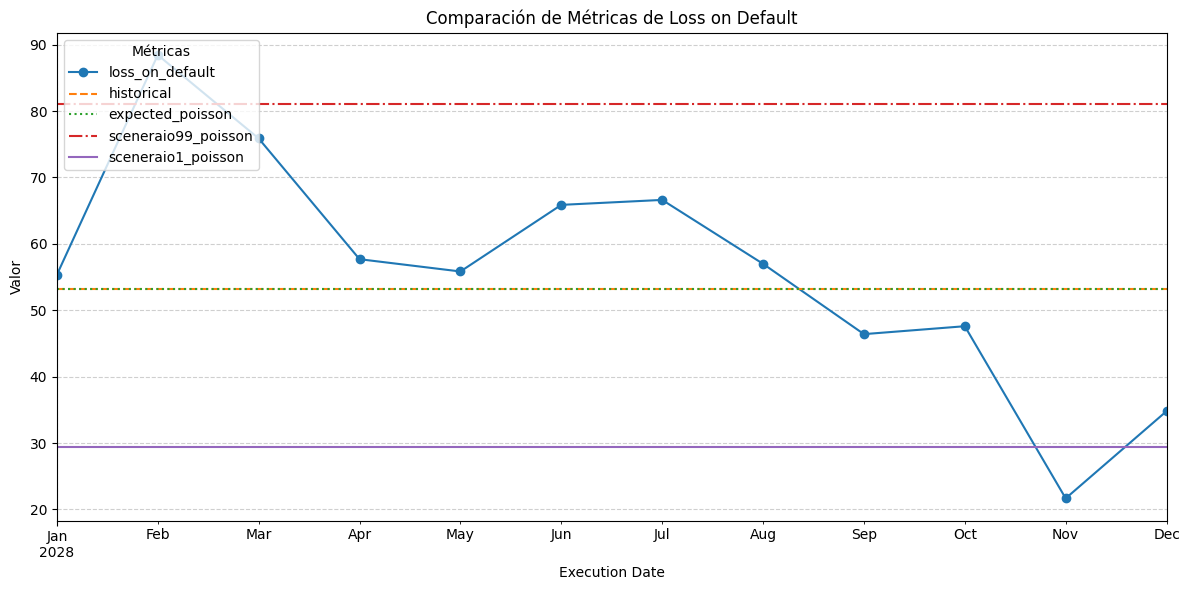

In [ ]:
import matplotlib.pyplot as plt

# Asegurar que el índice sea tipo datetime para que el eje X se vea limpio
results.index = pd.to_datetime(results.index)

# Graficar las 4 columnas directamente desde Pandas
ax = results.plot(
    figsize=(12, 6),
    style=['-o', '--', ':', '-.'], # Estilos de línea opcionales para mayor claridad
    title="Comparación de Métricas de Loss on Default"
)

# Personalizar etiquetas y leyenda
ax.set_xlabel("Execution Date")
ax.set_ylabel("Valor")
ax.legend(title="Métricas", loc="upper left")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Ajustemos... la exposición..
panel_train['new_default'].value_counts(normalize=True)

,proportion
new_default,
0,0.993908
1,0.006092


In [ ]:
panel_train

,id_credit,cohort,delivery_date,execution_date,age_months,term_months,original_amount,outstanding_balance,days_past_due,default_state,new_default,at_risk,lgd,ead_at_default,loss_on_default
0,1,2023-01,2023-01-01,2023-01-31,0,14,9.411862e+06,9.411862e+06,0,0,0,1,0.474948,0.0,0.0
1,1,2023-01,2023-01-01,2023-02-28,1,14,9.411862e+06,8.739586e+06,0,0,0,1,0.474948,0.0,0.0
2,1,2023-01,2023-01-01,2023-03-31,2,14,9.411862e+06,8.067310e+06,0,0,0,1,0.474948,0.0,0.0
3,1,2023-01,2023-01-01,2023-04-30,3,14,9.411862e+06,7.395034e+06,0,0,0,1,0.474948,0.0,0.0
4,1,2023-01,2023-01-01,2023-05-31,4,14,9.411862e+06,6.722759e+06,0,0,0,1,0.474948,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213209,16268,2027-12,2027-12-31,2027-12-31,0,14,1.609272e+07,1.609272e+07,0,0,0,1,0.291342,0.0,0.0
213210,16269,2027-12,2027-12-31,2027-12-31,0,14,3.000000e+07,3.000000e+07,0,0,0,1,0.425676,0.0,0.0
213211,16270,2027-12,2027-12-31,2027-12-31,0,15,7.372265e+06,7.372265e+06,0,0,0,1,0.429045,0.0,0.0
213212,16271,2027-12,2027-12-31,2027-12-31,0,18,1.084091e+07,1.084091e+07,0,0,0,1,0.220547,0.0,0.0


In [ ]:
N_t = panel_train.groupby('execution_date')['at_risk'].sum() # riesgo de su primer default

In [ ]:
D_t = panel_train.groupby('execution_date')['new_default'].sum()

In [ ]:
p_hat = (panel_train['new_default'].sum()/panel_train['at_risk'].sum())

In [ ]:
p_hat

np.float64(0.0063466781320539005)

In [ ]:
results_adj_size = (panel_test.groupby('execution_date')['at_risk'].sum().mul(p_hat).rename('lambda').reset_index())
results_adj_size['poisson_exposure_p05'] = poisson.ppf(0.05,results_adj_size['lambda'])
results_adj_size['poisson_exposure_p95'] = poisson.ppf(0.95,results_adj_size['lambda'])

In [ ]:
results_adj_size['mean_loss']  = mean_loss

In [ ]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss
0,2028-01-31,25.932527,18.0,35.0,53.140542
1,2028-02-29,27.157436,19.0,36.0,53.140542
2,2028-03-31,27.671517,19.0,37.0,53.140542
3,2028-04-30,27.963464,20.0,37.0,53.140542
4,2028-05-31,27.792104,19.0,37.0,53.140542
5,2028-06-30,27.252636,19.0,36.0,53.140542
6,2028-07-31,26.421221,18.0,35.0,53.140542
7,2028-08-31,25.450179,17.0,34.0,53.140542
8,2028-09-30,23.977750,16.0,32.0,53.140542
9,2028-10-31,22.454547,15.0,31.0,53.140542


In [ ]:
results_adj_size['scenario_95'] = results_adj_size['poisson_exposure_p95'] * severity
results_adj_size['scenario_5'] = results_adj_size['poisson_exposure_p05'] * severity
results_adj_size['poisson_loss'] = results_adj_size['lambda'] * severity
results_adj_size['loss_on_default'] = results['loss_on_default'].values

In [ ]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss,scenario_95,scenario_5,poisson_loss,loss_on_default
0,2028-01-31,25.932527,18.0,35.0,53.140542,85.908498,44.181513,63.652127,55.347953
1,2028-02-29,27.157436,19.0,36.0,53.140542,88.363026,46.636042,66.658700,88.444434
2,2028-03-31,27.671517,19.0,37.0,53.140542,90.817555,46.636042,67.920527,75.875779
3,2028-04-30,27.963464,20.0,37.0,53.140542,90.817555,49.090570,68.637119,57.689566
4,2028-05-31,27.792104,19.0,37.0,53.140542,90.817555,46.636042,68.216511,55.839205
5,2028-06-30,27.252636,19.0,36.0,53.140542,88.363026,46.636042,66.892372,65.872270
6,2028-07-31,26.421221,18.0,35.0,53.140542,85.908498,44.181513,64.851640,66.618243
7,2028-08-31,25.450179,17.0,34.0,53.140542,83.453969,41.726985,62.468191,56.991399
8,2028-09-30,23.977750,16.0,32.0,53.140542,78.544912,39.272456,58.854071,46.402188
9,2028-10-31,22.454547,15.0,31.0,53.140542,76.090384,36.817928,55.115326,47.595843


In [ ]:
results_adj_size

,execution_date,lambda,poisson_exposure_p05,poisson_exposure_p95,mean_loss,scenario_95,scenario_5,poisson_loss,loss_on_default
0,2028-01-31,25.932527,18.0,35.0,53.140542,85.908498,44.181513,63.652127,55.347953
1,2028-02-29,27.157436,19.0,36.0,53.140542,88.363026,46.636042,66.658700,88.444434
2,2028-03-31,27.671517,19.0,37.0,53.140542,90.817555,46.636042,67.920527,75.875779
3,2028-04-30,27.963464,20.0,37.0,53.140542,90.817555,49.090570,68.637119,57.689566
4,2028-05-31,27.792104,19.0,37.0,53.140542,90.817555,46.636042,68.216511,55.839205
5,2028-06-30,27.252636,19.0,36.0,53.140542,88.363026,46.636042,66.892372,65.872270
6,2028-07-31,26.421221,18.0,35.0,53.140542,85.908498,44.181513,64.851640,66.618243
7,2028-08-31,25.450179,17.0,34.0,53.140542,83.453969,41.726985,62.468191,56.991399
8,2028-09-30,23.977750,16.0,32.0,53.140542,78.544912,39.272456,58.854071,46.402188
9,2028-10-31,22.454547,15.0,31.0,53.140542,76.090384,36.817928,55.115326,47.595843


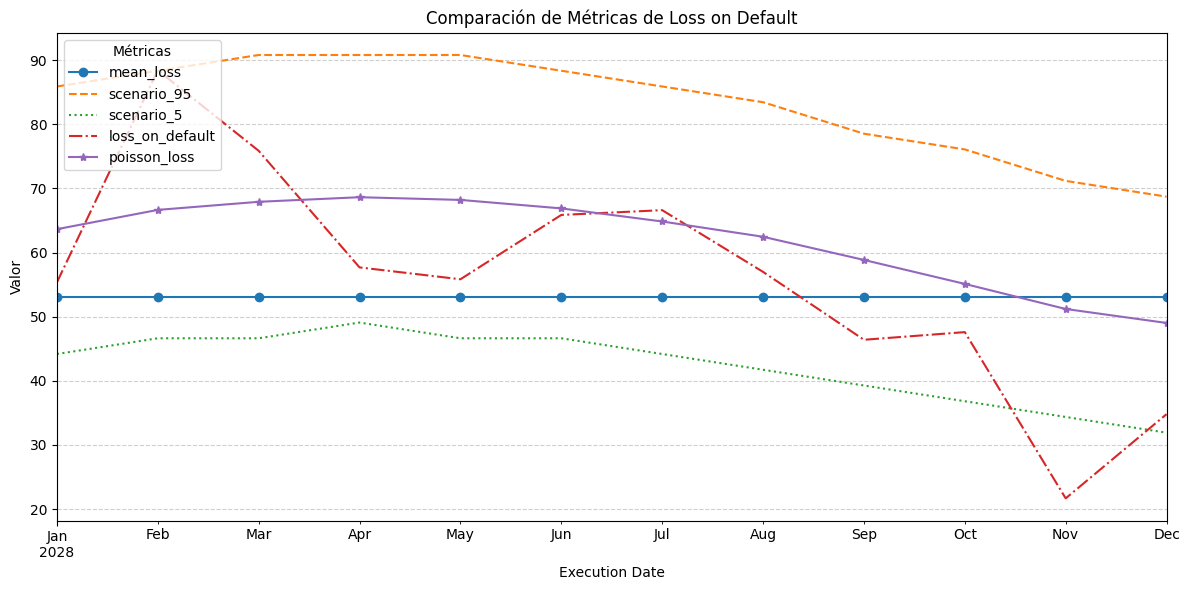

In [ ]:
results_adj_size.index = pd.to_datetime(results_adj_size['execution_date'])
ax = results_adj_size[['mean_loss', 'scenario_95', 'scenario_5', 'loss_on_default', 'poisson_loss']].plot(
    figsize=(12, 6),
    style=['-o', '--', ':', '-.','-*'],
    title="Comparación de Métricas de Loss on Default"
)
ax.set_xlabel("Execution Date")
ax.set_ylabel("Valor")
ax.legend(title="Métricas", loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
print((results_adj_size['loss_on_default'] - results_adj_size['mean_loss']).abs().sum()) # pérdida del histórico
print((results_adj_size['loss_on_default'] - results_adj_size['scenario_95']).abs().sum()) # pérdida de peor scenario
print((results_adj_size['loss_on_default'] - results_adj_size['poisson_loss']).abs().sum())# pérdida de poisson ajustada

159.64712190626614
326.0075125415811
133.3628645903873


In [ ]:
(133.3628645903873  - 159.64712190626614)  / 159.64712190626614 * 100

-16.463971916331296

In [ ]:
severity_data = panel_train.loc[
    panel_train["new_default"] == 1,
    "loss_on_default"
]

In [ ]:
severity_data.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,loss_on_default
count,1299.000000
mean,2.454529
std,2.097975
min,0.082005
1%,0.147636
5%,0.286485
25%,0.946757
50%,1.886178
75%,3.299630
95%,6.671645


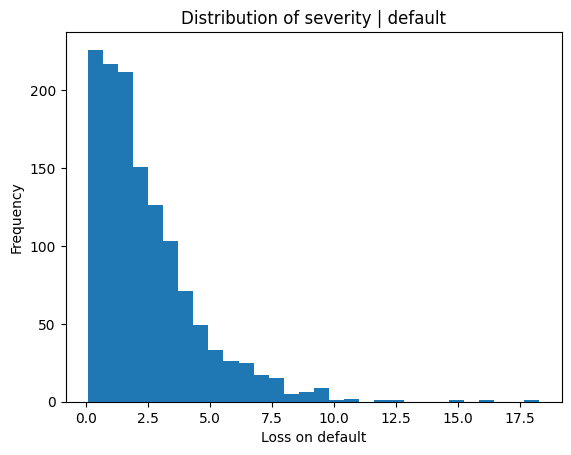

In [ ]:
plt.hist(severity_data, bins=30)
plt.xlabel("Loss on default")
plt.ylabel("Frequency")
plt.title("Distribution of severity | default")
plt.show()

cada Default genera una pérdida aletoria $X$ por lo que la pérdida agregada es

\begin{equation}
S = \sum_{i=1}^{N} X_{i}
\end{equation}